In [113]:
import os
import pandas as pd
import pickle
import ast
import torch

### Root to save csvs

In [114]:
root_save_dir = "CUB_analysis_csv"

In [115]:
# Build up CUB dataframe
splits_pkl = ["train.pkl", "val.pkl", "test.pkl"]

root_cbm = os.path.join("datasets", "CUB", "class_attr_data_10")

df_cub = pd.DataFrame()

for split in splits_pkl:
    split_path = os.path.join(root_cbm, split)
    # list of dictionaries, each dictionary is a row in the dataframe
    pkl_data = pd.read_pickle(split_path)
    df_split = pd.DataFrame(pkl_data)
    df_cub = pd.concat([df_cub, df_split], ignore_index=True)
    
    
df_cub.head(10)

,id,img_path,class_label,attribute_label,attribute_certainty
0,1210,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,21,"[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
1,2987,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,51,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
2,3621,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,62,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, ..."
3,9938,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,168,"[0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, ...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, ..."
4,41,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
5,4097,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,70,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, ..."
6,1366,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,24,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
7,5878,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,100,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
8,5631,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,96,"[0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ..."
9,7426,/juice/scr/scr102/scr/thaonguyen/CUB_supervisi...,126,"[0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, ..."


## Class idx to class name

In [116]:
# Count how many unique bird species are in each split
for split in splits_pkl:
    split_path = os.path.join(root_cbm, split)
    pkl_data = pd.read_pickle(split_path)
    df_split = pd.DataFrame(pkl_data)
    num_unique_species = df_split["class_label"].nunique()
    max_class_label = df_split["class_label"].max()
    min_class_label = df_split["class_label"].min()
    # get range 
    print(f"Split: {split}, Number of unique species: {num_unique_species}, Range: {min_class_label} - {max_class_label}")

Split: train.pkl, Number of unique species: 200, Range: 0 - 199
Split: val.pkl, Number of unique species: 200, Range: 0 - 199
Split: test.pkl, Number of unique species: 200, Range: 0 - 199


In [117]:
class_names = pd.read_csv(os.path.join("datasets", "CUB/CUB_200_2011//CUB_200_2011/classes.txt"), sep=" ", header=None, names=["class_id", "class_name"])
# 0 index the class_idx
class_names["class_id"] = class_names["class_id"] - 1



## 112 Concepts

In [118]:


ATTRIBUTES_IDX_USED = [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, \
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, \
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, \
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]




def get_attribute_parts_to_indices():
    """
    Maps attribute idx to attribute parts (e.g. bill, wing, etc.)
    """
    
    
    # Attribute idx in the original 312 attribute space to attribute idx in the new 112 attribute space
    old_idx_to_new_idx = {old_idx: new_idx for new_idx, old_idx in enumerate(ATTRIBUTES_IDX_USED)}
    #print(old_idx_to_new_idx)
    

    path_attrubute_file = os.path.join("datasets", "CUB/CUB_200_2011/attributes.txt")



    with open(path_attrubute_file, "r") as f:
        lines = f.readlines()
        semantic_groups = {}
        for line in lines:
            idx, attr_name = line.strip().split(" ")
            idx = int(idx) - 1 # Convert to 0-based index
            if idx not in ATTRIBUTES_IDX_USED:
                continue
                
            new_idx = old_idx_to_new_idx[idx]
            semantic_group = attr_name.split("::")[0]
            if semantic_group not in semantic_groups:
                semantic_groups[semantic_group] = []
            semantic_groups[semantic_group].append(new_idx)

        return semantic_groups
    

get_attribute_parts_to_indices()

{'has_bill_shape': [0, 1, 2, 3],
 'has_wing_color': [4, 5, 6, 7, 8, 9],
 'has_upperparts_color': [10, 11, 12, 13, 14, 15],
 'has_underparts_color': [16, 17, 18, 19, 20, 21],
 'has_breast_pattern': [22, 23, 24],
 'has_back_color': [25, 26, 27, 28, 29, 30],
 'has_tail_shape': [31],
 'has_upper_tail_color': [32, 33, 34, 35, 36],
 'has_head_pattern': [37, 38],
 'has_breast_color': [39, 40, 41, 42, 43, 44],
 'has_throat_color': [45, 46, 47, 48, 49],
 'has_eye_color': [50],
 'has_bill_length': [51, 52],
 'has_forehead_color': [53, 54, 55, 56, 57, 58],
 'has_under_tail_color': [59, 60, 61, 62, 63],
 'has_nape_color': [64, 65, 66, 67, 68, 69],
 'has_belly_color': [70, 71, 72, 73, 74, 75],
 'has_wing_shape': [76, 77],
 'has_size': [78, 79, 80],
 'has_shape': [81, 82],
 'has_back_pattern': [83, 84, 85],
 'has_tail_pattern': [86, 87, 88],
 'has_belly_pattern': [89],
 'has_primary_color': [90, 91, 92, 93, 94, 95],
 'has_leg_color': [96, 97, 98],
 'has_bill_color': [99, 100, 101],
 'has_crown_color

In [119]:
def get_attribute_names():
    """
    Maps attribute idx to attribute names
    """
    
    # Attribute idx in the original 312 attribute space to attribute idx in the new 112 attribute space
    old_idx_to_new_idx = {old_idx: new_idx for new_idx, old_idx in enumerate(ATTRIBUTES_IDX_USED)}
    #print(old_idx_to_new_idx)
    

    path_attrubute_file = os.path.join("datasets", "CUB/CUB_200_2011/attributes.txt")



    with open(path_attrubute_file, "r") as f:
        lines = f.readlines()
        attribute_names = {}
        for line in lines:
            idx, attr_name = line.strip().split(" ")
            idx = int(idx) - 1 # Convert to 0-based index
            if idx not in ATTRIBUTES_IDX_USED:
                continue
                
            new_idx = old_idx_to_new_idx[idx]
            attribute_names[new_idx] = attr_name

        return attribute_names
    
attr_idx_to_names = get_attribute_names()

df_attr_idx_to_names = pd.DataFrame(list(attr_idx_to_names.items()), columns=["idx", "name"])
df_attr_idx_to_names.to_csv(os.path.join(root_save_dir, "112_concepts.csv"), index=False)
df_attr_idx_to_names.head(10)



,idx,name
0,0,has_bill_shape::dagger
1,1,has_bill_shape::hooked_seabird
2,2,has_bill_shape::all-purpose
3,3,has_bill_shape::cone
4,4,has_wing_color::brown
5,5,has_wing_color::grey
6,6,has_wing_color::yellow
7,7,has_wing_color::black
8,8,has_wing_color::white
9,9,has_wing_color::buff


## Dataset with samples and attributes

In [120]:
# From df_cub expand with attribute names and for each sample 0 or 1 for each attribute
attr_names = [attr_idx_to_names[i] for i in range(len(attr_idx_to_names))]

df_attrs = pd.DataFrame(
    df_cub["attribute_label"].tolist(),
    columns=attr_names,
    index=df_cub.index,
    dtype="int8",
)

df_samples = pd.concat([df_cub[["id", "class_label"]], df_attrs], axis=1)

# Add class_name as well
class_id_to_name = dict(zip(class_names["class_id"], class_names["class_name"]))
df_samples.insert(2, "class_name", df_samples["class_label"].map(class_id_to_name))
assert df_samples["class_name"].notna().all()

df_samples.to_csv(os.path.join(root_save_dir, "samples_attributes.csv"), index=False)
print(df_samples.shape)
df_samples.head(10)


(11788, 115)


,id,class_label,class_name,has_bill_shape::dagger,has_bill_shape::hooked_seabird,has_bill_shape::all-purpose,has_bill_shape::cone,has_wing_color::brown,has_wing_color::grey,has_wing_color::yellow,...,has_crown_color::blue,has_crown_color::brown,has_crown_color::grey,has_crown_color::yellow,has_crown_color::black,has_crown_color::white,has_wing_pattern::solid,has_wing_pattern::spotted,has_wing_pattern::striped,has_wing_pattern::multi-colored
0,1210,21,022.Chuck_will_Widow,0,0,0,1,1,0,0,...,0,1,0,0,0,0,0,1,0,0
1,2987,51,052.Pied_billed_Grebe,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
2,3621,62,063.Ivory_Gull,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
3,9938,168,169.Magnolia_Warbler,0,0,1,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
4,41,0,001.Black_footed_Albatross,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4097,70,071.Long_tailed_Jaeger,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
6,1366,24,025.Pelagic_Cormorant,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
7,5878,100,101.White_Pelican,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
8,5631,96,097.Orchard_Oriole,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
9,7426,126,127.Savannah_Sparrow,0,0,0,1,1,0,0,...,0,1,0,0,0,0,0,0,1,0


## List all yellow attributes

In [121]:
# List all yellow attributes
yellow_attributes = [attr for attr in attr_idx_to_names.values() if 'yellow' in attr.lower()]
print("Yellow attributes:", yellow_attributes)
print("Number of yellow attributes:", len(yellow_attributes))

Yellow attributes: ['has_wing_color::yellow', 'has_upperparts_color::yellow', 'has_underparts_color::yellow', 'has_back_color::yellow', 'has_breast_color::yellow', 'has_throat_color::yellow', 'has_forehead_color::yellow', 'has_nape_color::yellow', 'has_belly_color::yellow', 'has_primary_color::yellow', 'has_crown_color::yellow']
Number of yellow attributes: 11


## Remove attribute groups and individual concepts

In [122]:
ATTRIBUTE_PARTS = [
 'has_bill_shape',
 'has_wing_color',
 'has_upperparts_color',
 'has_underparts_color',
 'has_breast_pattern',
 'has_back_color',
 'has_tail_shape',
 'has_upper_tail_color',
 'has_head_pattern',
 'has_breast_color',
 'has_throat_color',
 'has_eye_color',
 'has_bill_length',
 'has_forehead_color',
 'has_under_tail_color',
 'has_nape_color',
 'has_belly_color',
 'has_wing_shape',
 'has_size',
 'has_shape',
 'has_back_pattern',
 'has_tail_pattern',
 'has_belly_pattern',
 'has_primary_color',
 'has_leg_color',
 'has_bill_color',
 'has_crown_color',
 'has_wing_pattern',
]






    
    
def create_random_incomplete_dataset_attr_groups(
    remove_attribute_parts_remove, extra_remove_indices=None, new_folder_name=None
    ):
    
    attribute_parts_indices_map = get_attribute_parts_to_indices()
    num_concepts = 112
    num_attribute_groups_remove = len(remove_attribute_parts_remove)

    remove_set = set()
    for part in remove_attribute_parts_remove:
        remove_set.update(attribute_parts_indices_map[part])
    if extra_remove_indices is not None:
        remove_set.update(extra_remove_indices)

 

    
    
    num_attributes_remaining = num_concepts - len(remove_set)
    
    path_to_incomplete_data_folder = os.path.join("datasets", "CUB", "incomplete_data")
    os.makedirs(path_to_incomplete_data_folder, exist_ok=True)
    
    if new_folder_name is not None:
        new_pkl_dir = new_folder_name
    else:
        new_pkl_dir = "class_attr_data_10_incomplete"
    
    # Create new pkl folder
    largest_digit = 0
    hostname = os.uname()[1]
    for folder_name in os.listdir(path_to_incomplete_data_folder):
        full_pkl_name = new_pkl_dir + "_"
        if full_pkl_name in folder_name:
            last_digit = folder_name.split("_")[-1]
            if last_digit.isdigit():
                largest_digit = max(largest_digit, int(last_digit))
                

        
    if "biomed" in hostname:
        new_pkl_dir = new_pkl_dir + f"_cluster_{largest_digit + 1}/"
    else: 
        new_pkl_dir = new_pkl_dir + f"_local_{largest_digit + 1}/"
    
    new_folder_path = os.path.join(path_to_incomplete_data_folder,
                                   new_pkl_dir)
    os.makedirs(new_folder_path, exist_ok=True)
    
    # Create mapping from old attribute indices to new attribute indices after removal, for info.txt
    old_to_new_attr_idx = {}
    new_idx = 0
    for old_idx in range(num_concepts):
        if old_idx not in remove_set:
            old_to_new_attr_idx[old_idx] = new_idx
            new_idx += 1
   
    # Save info about the removed attribute groups and indices in a txt file in the new folder
    info_txt_path = os.path.join(new_folder_path, "info.txt")
    with open(info_txt_path, "w") as f:
        f.write(f"Mode: remove attribute groups\n")
        f.write(f"Removed attribute groups: {remove_attribute_parts_remove}\n")
        f.write(f"Removed attribute indices: {sorted(remove_set)}\n")
        f.write(f"Number of attribute groups fully removed: {num_attribute_groups_remove}\n")
        f.write(f"Total number of attributes removed: {len(remove_set)}\n")
        f.write(f"Number of attributes remaining: {num_attributes_remaining}\n")
        f.write(f"Extra removed attribute indices: {sorted(extra_remove_indices) if extra_remove_indices is not None else []}\n")
        # This is only used if you want to intervene on specific attribute groups and need to know which attribute indices correspond to which groups after the random removal
        f.write(f"New attribute indices mapping: {old_to_new_attr_idx}\n")
    
    
    
    
    #Modify pkl files and save to new folder
    pkl_files = ["train.pkl", "val.pkl", "test.pkl"]
    old_folder_path = os.path.join("datasets", "CUB", "class_attr_data_10")
    for pkl_file in pkl_files:
        pkl_path = os.path.join(old_folder_path, pkl_file)
        data = pickle.load(open(pkl_path, "rb"))
        
        for sample in data:
            sample["attribute_label"] = [
                v for i, v in enumerate(sample["attribute_label"]) if i not in remove_set
            ]
        new_pkl_path = os.path.join(new_folder_path, pkl_file)
        with open(new_pkl_path, "wb") as f:
            pickle.dump(data, f)
        print(f"Saved modified {pkl_file} to {new_pkl_path}")

    return new_pkl_dir, num_attributes_remaining



    
    



In [123]:
DROP_GROUPS = [
    "has_upperparts_color", "has_back_color", "has_nape_color",
    "has_primary_color", "has_forehead_color", "has_upper_tail_color",
    "has_under_tail_color", "has_wing_pattern", "has_breast_pattern",
    "has_back_pattern", "has_tail_pattern", "has_size", "has_leg_color",
    "has_bill_color", "has_head_pattern", "has_bill_length", "has_shape",
    "has_tail_shape", "has_belly_pattern", "has_eye_color",
]

PLANTED_DROP = [
    "has_breast_color::yellow", "has_belly_color::yellow",
    "has_underparts_color::yellow", "has_throat_color::yellow",
]

idx_attribute_idx_drop = [idx for idx, name in attr_idx_to_names.items() if name in PLANTED_DROP]

#create_random_incomplete_dataset_attr_groups(remove_attribute_parts_remove=DROP_GROUPS, extra_remove_indices=idx_attribute_idx_drop, new_folder_name="yellow_experiment")

attr_idx_to_names

{0: 'has_bill_shape::dagger',
 1: 'has_bill_shape::hooked_seabird',
 2: 'has_bill_shape::all-purpose',
 3: 'has_bill_shape::cone',
 4: 'has_wing_color::brown',
 5: 'has_wing_color::grey',
 6: 'has_wing_color::yellow',
 7: 'has_wing_color::black',
 8: 'has_wing_color::white',
 9: 'has_wing_color::buff',
 10: 'has_upperparts_color::brown',
 11: 'has_upperparts_color::grey',
 12: 'has_upperparts_color::yellow',
 13: 'has_upperparts_color::black',
 14: 'has_upperparts_color::white',
 15: 'has_upperparts_color::buff',
 16: 'has_underparts_color::brown',
 17: 'has_underparts_color::grey',
 18: 'has_underparts_color::yellow',
 19: 'has_underparts_color::black',
 20: 'has_underparts_color::white',
 21: 'has_underparts_color::buff',
 22: 'has_breast_pattern::solid',
 23: 'has_breast_pattern::striped',
 24: 'has_breast_pattern::multi-colored',
 25: 'has_back_color::brown',
 26: 'has_back_color::grey',
 27: 'has_back_color::yellow',
 28: 'has_back_color::black',
 29: 'has_back_color::white',
 30:

## Yellow experiment

In [124]:
# Check which attributes are kept 
yellow_dir = os.path.join("datasets", "CUB", "incomplete_data", "yellow_experiment_local_1")

with open(os.path.join(yellow_dir, "info.txt"), "r") as f:
    info_content = f.read()
    print(info_content)

# old (112-dim) attribute idx -> idx in the surviving 37-dim concept space
mapping_line = next(
    line for line in info_content.splitlines()
    if line.startswith("New attribute indices mapping: ")
)
attr_idx_mapping_dict = ast.literal_eval(mapping_line.split(": ", 1)[1])
inv_attr_idx_mapping_dict = {new: old for old, new in attr_idx_mapping_dict.items()}

kept_attr_names = {new: attr_idx_to_names[old] for old, new in attr_idx_mapping_dict.items()}

print(f"{len(attr_idx_mapping_dict)} concepts kept")
kept_attr_names


Mode: remove attribute groups
Removed attribute groups: ['has_upperparts_color', 'has_back_color', 'has_nape_color', 'has_primary_color', 'has_forehead_color', 'has_upper_tail_color', 'has_under_tail_color', 'has_wing_pattern', 'has_breast_pattern', 'has_back_pattern', 'has_tail_pattern', 'has_size', 'has_leg_color', 'has_bill_color', 'has_head_pattern', 'has_bill_length', 'has_shape', 'has_tail_shape', 'has_belly_pattern', 'has_eye_color']
Removed attribute indices: [10, 11, 12, 13, 14, 15, 18, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 41, 46, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 72, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 108, 109, 110, 111]
Number of attribute groups fully removed: 20
Total number of attributes removed: 75
Number of attributes remaining: 37
Extra removed attribute indices: [18, 41, 46, 72]
New attribute indices mapping: {0: 0, 1: 1, 2: 2, 3:

{0: 'has_bill_shape::dagger',
 1: 'has_bill_shape::hooked_seabird',
 2: 'has_bill_shape::all-purpose',
 3: 'has_bill_shape::cone',
 4: 'has_wing_color::brown',
 5: 'has_wing_color::grey',
 6: 'has_wing_color::yellow',
 7: 'has_wing_color::black',
 8: 'has_wing_color::white',
 9: 'has_wing_color::buff',
 10: 'has_underparts_color::brown',
 11: 'has_underparts_color::grey',
 12: 'has_underparts_color::black',
 13: 'has_underparts_color::white',
 14: 'has_underparts_color::buff',
 15: 'has_breast_color::brown',
 16: 'has_breast_color::grey',
 17: 'has_breast_color::black',
 18: 'has_breast_color::white',
 19: 'has_breast_color::buff',
 20: 'has_throat_color::grey',
 21: 'has_throat_color::black',
 22: 'has_throat_color::white',
 23: 'has_throat_color::buff',
 24: 'has_belly_color::brown',
 25: 'has_belly_color::grey',
 26: 'has_belly_color::black',
 27: 'has_belly_color::white',
 28: 'has_belly_color::buff',
 29: 'has_wing_shape::rounded-wings',
 30: 'has_wing_shape::pointed-wings',
 31: 

### Classes with exact same ground truth concept sets

In [125]:
import numpy as np

# ---- load the incomplete (37-dim) split ---------------------------------
df_yellow = pd.concat(
    [pd.DataFrame(pd.read_pickle(os.path.join(yellow_dir, s)))
     for s in ["train.pkl", "val.pkl", "test.pkl"]],
    ignore_index=True,
)
A = np.stack(df_yellow["attribute_label"].to_numpy()).astype(np.int8)
y = df_yellow["class_label"].to_numpy()
print("samples:", A.shape[0], "concepts:", A.shape[1], "classes:", len(np.unique(y)))

# ---- sanity check: exactly one activation vector per class --------------
class_vec, inconsistent = {}, []
for c in np.unique(y):
    rows = np.unique(A[y == c], axis=0)
    if len(rows) > 1:
        inconsistent.append((int(c), len(rows)))
    class_vec[int(c)] = rows[0]
print("classes with >1 distinct activation vector:", len(inconsistent), inconsistent[:10])

classes = np.array(sorted(class_vec))
M = np.stack([class_vec[c] for c in classes])          # (200, 37)

# ---- group classes by identical activation ------------------------------
def collision_groups(M, classes):
    groups = {}
    for c, row in zip(classes, M):
        groups.setdefault(row.tobytes(), []).append(int(c))
    return [g for g in groups.values() if len(g) > 1]

groups_37 = collision_groups(M, classes)
print(f"{len(np.unique(M, axis=0))} distinct vectors for {len(classes)} classes "
      f"-> {len(groups_37)} collision groups covering "
      f"{sum(len(g) for g in groups_37)} classes")


samples: 11788 concepts: 37 classes: 200
classes with >1 distinct activation vector: 0 []
175 distinct vectors for 200 classes -> 16 collision groups covering 41 classes


In [126]:
# ---- print the colliding classes, grouped --------------------------------
cls_pos = {int(c): i for i, c in enumerate(classes)}   # class_label -> row in M

for gi, g in enumerate(sorted(groups_37, key=lambda g: (-len(g), g[0]))):
    n_active = int(M[cls_pos[g[0]]].sum())
    print(f"\nGroup {gi} — {len(g)} classes ({n_active} active concepts)")
    for c in sorted(g):
        print(f"  {c:3d}  {class_id_to_name[c]}")

# which concepts are on, for each group
print("\n--- active concepts per group ---")
for gi, g in enumerate(sorted(groups_37, key=lambda g: (-len(g), g[0]))):
    on = [kept_attr_names[j] for j in np.flatnonzero(M[cls_pos[g[0]]])]
    print(f"Group {gi}: {on if on else '<none — all-zero vector>'}")



Group 0 — 5 classes (2 active concepts)
   41  042.Vermilion_Flycatcher
   42  043.Yellow_bellied_Flycatcher
  162  163.Cape_May_Warbler
  172  173.Orange_crowned_Warbler
  173  174.Palm_Warbler

Group 1 — 4 classes (6 active concepts)
    3  004.Groove_billed_Ani
   24  025.Pelagic_Cormorant
   25  026.Bronzed_Cowbird
  107  108.White_necked_Raven

Group 2 — 4 classes (8 active concepts)
   59  060.Glaucous_winged_Gull
   61  062.Herring_Gull
   64  065.Slaty_backed_Gull
   65  066.Western_Gull

Group 3 — 3 classes (8 active concepts)
    8  009.Brewer_Blackbird
   28  029.American_Crow
   48  049.Boat_tailed_Grackle

Group 4 — 3 classes (7 active concepts)
  142  143.Caspian_Tern
  144  145.Elegant_Tern
  145  146.Forsters_Tern

Group 5 — 2 classes (7 active concepts)
    9  010.Red_winged_Blackbird
  106  107.Common_Raven

Group 6 — 2 classes (3 active concepts)
   13  014.Indigo_Bunting
   15  016.Painted_Bunting

Group 7 — 2 classes (2 active concepts)
   17  018.Spotted_Catbird


## Linear classifier

In [127]:
lin_dir = os.path.join("experiments", "linear_head", "CUB",
                       "yellow_experiment_local_1_2026-09-02_15-03-59_5d483")


In [128]:

y_pred_logits = torch.load(os.path.join(lin_dir, "y_pred.pt"), map_location="cpu")
y_true = torch.load(os.path.join(lin_dir, "y_true.pt"), map_location="cpu")
y_hat = y_pred_logits.argmax(1) if y_pred_logits.ndim == 2 else y_pred_logits
y_hat, y_true = y_hat.numpy(), y_true.numpy()

correct = (y_hat == y_true)
print(f"{len(y_true)} samples, {correct.sum()} correct, overall acc = {correct.mean():.4f}")

# ---- per-class counts + accuracy ----------------------------------------
df_acc = (pd.DataFrame({"class_label": y_true, "correct": correct})
          .groupby("class_label")["correct"].agg(n_samples="size", n_correct="sum")
          .reset_index())
df_acc["accuracy"] = df_acc["n_correct"] / df_acc["n_samples"]
df_acc.insert(1, "class_name", df_acc["class_label"].map(class_id_to_name))

# tag each class with its collision group (NaN = activation vector is unique)
ordered_groups = sorted(groups_37, key=lambda g: (-len(g), g[0]))
cls_to_group = {c: gi for gi, g in enumerate(ordered_groups) for c in g}
df_acc["collision_group"] = df_acc["class_label"].map(cls_to_group)
df_acc["group_size"] = df_acc["collision_group"].map(
    {gi: len(g) for gi, g in enumerate(ordered_groups)})

df_acc.to_csv(os.path.join(root_save_dir,
              "yellow_experiment_linear_head_per_class_acc.csv"), index=False)

print("\nworst 25 classes")
print(df_acc.sort_values(["accuracy", "class_label"]).head(25).to_string(index=False))

# ---- colliding vs unique classes ----------------------------------------
coll = df_acc["collision_group"].notna()
for label, mask in [("colliding", coll), ("unique", ~coll)]:
    n, k = df_acc.loc[mask, "n_samples"].sum(), df_acc.loc[mask, "n_correct"].sum()
    print(f"{label:9s} classes ({mask.sum():3d}): acc = {k/n:.4f}  ({k}/{n})")

# ---- accuracy per collision group ---------------------------------------
df_grp = (df_acc[coll].groupby(["collision_group", "group_size"])[["n_samples", "n_correct"]]
          .sum().reset_index())
df_grp["accuracy"] = df_grp["n_correct"] / df_grp["n_samples"]
df_grp["classes_the_head_ever_predicts"] = df_grp["collision_group"].map(
    lambda gi: [class_id_to_name[int(c)] for c in sorted(set(y_hat[np.isin(y_true, ordered_groups[int(gi)])]))])
print()
print(df_grp.to_string(index=False))

5794 samples, 5086 correct, overall acc = 0.8778

worst 25 classes
 class_label                    class_name  n_samples  n_correct  accuracy  collision_group  group_size
           3         004.Groove_billed_Ani         30          0       0.0              1.0         4.0
           8          009.Brewer_Blackbird         29          0       0.0              3.0         3.0
           9      010.Red_winged_Blackbird         30          0       0.0              5.0         2.0
          15           016.Painted_Bunting         28          0       0.0              6.0         2.0
          17           018.Spotted_Catbird         15          0       0.0              7.0         2.0
          23       024.Red_faced_Cormorant         22          0       0.0              9.0         2.0
          24         025.Pelagic_Cormorant         30          0       0.0              1.0         4.0
          41      042.Vermilion_Flycatcher         30          0       0.0              0.0         5

## Per-class accuracy: Res-SCBM (20 res), L_int_ext w=1

Same overview as the linear head above, on the model's own saved test
predictions -- identical 5794-sample test split, so the two are comparable.
Defines `df_acc_res20_lint`, used by the comparison cell below.

In [129]:
def per_class_overview(pred_dir, csv_name, top_n=25):
    """Per-class accuracy + collision-group breakdown for a run's saved test predictions.

    pred_dir must hold y_pred.pt / y_true.pt -- the linear head and the SCBM family all
    dump the same two tensors, so any run folder works.
    """
    y_pred_logits = torch.load(os.path.join(pred_dir, "y_pred.pt"), map_location="cpu")
    y_true = torch.load(os.path.join(pred_dir, "y_true.pt"), map_location="cpu")
    y_hat = y_pred_logits.argmax(1) if y_pred_logits.ndim == 2 else y_pred_logits
    y_hat, y_true = y_hat.numpy().ravel(), y_true.numpy().ravel()

    correct = (y_hat == y_true)
    print(f"{len(y_true)} samples, {correct.sum()} correct, overall acc = {correct.mean():.4f}")

    # ---- per-class counts + accuracy ----------------------------------------
    df_acc = (pd.DataFrame({"class_label": y_true, "correct": correct})
              .groupby("class_label")["correct"].agg(n_samples="size", n_correct="sum")
              .reset_index())
    df_acc["accuracy"] = df_acc["n_correct"] / df_acc["n_samples"]
    df_acc.insert(1, "class_name", df_acc["class_label"].map(class_id_to_name))

    # tag each class with its collision group (NaN = activation vector is unique)
    ordered_groups = sorted(groups_37, key=lambda g: (-len(g), g[0]))
    cls_to_group = {c: gi for gi, g in enumerate(ordered_groups) for c in g}
    df_acc["collision_group"] = df_acc["class_label"].map(cls_to_group)
    df_acc["group_size"] = df_acc["collision_group"].map(
        {gi: len(g) for gi, g in enumerate(ordered_groups)})
    df_acc.to_csv(os.path.join(root_save_dir, csv_name), index=False)

    print(f"\nworst {top_n} classes")
    print(df_acc.sort_values(["accuracy", "class_label"]).head(top_n).to_string(index=False))

    # ---- colliding vs unique classes ----------------------------------------
    coll = df_acc["collision_group"].notna()
    print()
    for label, mask in [("colliding", coll), ("unique", ~coll)]:
        n, k = df_acc.loc[mask, "n_samples"].sum(), df_acc.loc[mask, "n_correct"].sum()
        print(f"{label:9s} classes ({mask.sum():3d}): acc = {k/n:.4f}  ({k}/{n})")

    # ---- accuracy per collision group ---------------------------------------
    df_grp = (df_acc[coll].groupby(["collision_group", "group_size"])[["n_samples", "n_correct"]]
              .sum().reset_index())
    df_grp["accuracy"] = df_grp["n_correct"] / df_grp["n_samples"]
    df_grp["classes_the_head_ever_predicts"] = df_grp["collision_group"].map(
        lambda gi: [class_id_to_name[int(c)] for c in sorted(set(y_hat[np.isin(y_true, ordered_groups[int(gi)])]))])
    print()
    print(df_grp.to_string(index=False))
    return df_acc, df_grp


# Same run folder as res_scbm_yellow_20_L_int_ext below; spelled out so this cell
# does not depend on a cell further down the notebook.
res20_lint_dir = os.path.join(
    "experiments", "scbm_residual", "CUB",
    "yellow_experiment_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-09-02_16-12-55_d1750",
    "test")
df_acc_res20_lint, df_grp_res20_lint = per_class_overview(
    res20_lint_dir, "yellow_experiment_res_scbm_20_L_int_ext_per_class_acc.csv")

5794 samples, 3911 correct, overall acc = 0.6750

worst 25 classes
 class_label                    class_name  n_samples  n_correct  accuracy  collision_group  group_size
           8          009.Brewer_Blackbird         29          0  0.000000              3.0         3.0
          61              062.Herring_Gull         30          0  0.000000              2.0         4.0
          65              066.Western_Gull         30          0  0.000000              2.0         4.0
         142              143.Caspian_Tern         30          0  0.000000              4.0         3.0
         144              145.Elegant_Tern         30          0  0.000000              4.0         3.0
         173              174.Palm_Warbler         30          3  0.100000              0.0         5.0
          28             029.American_Crow         30          6  0.200000              3.0         3.0
         141                142.Black_Tern         30          6  0.200000              NaN         N

## Intervention curves (yellow experiment)

In [130]:
# ---- Yellow-experiment runs ----
# All five share the same incomplete split (yellow_experiment_local_1/, 37 surviving concepts,
# every "yellow" attribute removed), so their intervention curves are directly comparable.
# Listed explicitly so that adding runs to experiments/ cannot silently change this plot.
scbm_yellow = "yellow_experiment_2026-09-02_16-14-57_36d68"
res_scbm_yellow_20 = "yellow_experiment_fixed_emp_perc_residuals_20_2026-09-02_16-14-31_a83bc"
res_scbm_yellow_20_L_int_ext = "yellow_experiment_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-09-02_16-12-55_d1750"
res_scbm_yellow_50 = "yellow_experiment_fixed_emp_perc_residuals_50_2026-09-02_16-14-31_98329"
res_scbm_yellow_50_L_int_ext = "yellow_experiment_fixed_emp_perc_residuals_50_L_int_extension_loss_weight_1_2026-09-02_16-14-34_3c050"

# (label, model_type, run_dir) -- model_type selects the experiments/<model_type>/CUB/ subfolder
YELLOW_RUNS = [
    ("SCBM",                             "scbm",          scbm_yellow),
    ("Res-SCBM (20 res)",                "scbm_residual", res_scbm_yellow_20),
    ("Res-SCBM (50 res)",                "scbm_residual", res_scbm_yellow_50),
    ("Res-SCBM (20 res), L_int_ext w=1", "scbm_residual", res_scbm_yellow_20_L_int_ext),
    ("Res-SCBM (50 res), L_int_ext w=1", "scbm_residual", res_scbm_yellow_50_L_int_ext),
]

# One colour per label, so the same model is the same colour in every panel.
YELLOW_COLORS = {
    "SCBM":                             "#2a78d6",
    "Res-SCBM (20 res)":                "#eb6834",
    "Res-SCBM (50 res)":                "#eda100",
    "Res-SCBM (20 res), L_int_ext w=1": "#1baf7a",
    "Res-SCBM (50 res), L_int_ext w=1": "#9b59b6",
}

In [131]:
import re
import ast

import matplotlib.pyplot as plt


def read_run_config(run_path):
    """First line of log.txt is the full config dict."""
    with open(os.path.join(run_path, "log.txt"), "r") as f:
        return ast.literal_eval(f.readline().strip())


def extract_info_from_intervention_log(model_dir, model_type="scbm", dataset="CUB",
                                       experiment_dir="experiments"):
    """Parse <run>/intervention_log.txt into (xs, {metric: [values]}).

    Later lines only carry a subset of the metrics (once every concept is intervened on there is
    no concept loss left to report), so metrics are read per line and missing ones come back as
    None rather than shifting the columns.
    """
    log_path = os.path.join(experiment_dir, model_type, dataset, model_dir, "intervention_log.txt")
    metrics = ["y_accuracy", "c_accuracy", "y_AUROC", "c_AUROC", "target_loss"]
    xs, out = [], {m: [] for m in metrics}
    with open(log_path, "r") as f:
        for line in f:
            m = re.search(r"Intervention on (\d+) concepts", line)
            if not m:
                continue
            xs.append(int(m.group(1)))
            for name in metrics:
                v = re.search(rf"\b{name}:\s*([0-9.]+)", line)
                scale = 1.0 if name.endswith("loss") else 100.0
                out[name].append(float(v.group(1)) * scale if v else None)
    return xs, out


# Sanity check: every run must be the same incomplete split, else the curves are not comparable.
splits = {(lbl, read_run_config(os.path.join("experiments", mt, "CUB", d))["data"]["pkl_file_dir"],
           read_run_config(os.path.join("experiments", mt, "CUB", d))["data"]["num_concepts"])
          for lbl, mt, d in YELLOW_RUNS}
for lbl, pkl, k in sorted(splits):
    print(f"{lbl:35s} pkl_file_dir={pkl:30s} num_concepts={k}")
assert len({(p, k) for _, p, k in splits}) == 1, "runs use different incomplete splits"

Res-SCBM (20 res)                   pkl_file_dir=yellow_experiment_local_1/     num_concepts=37
Res-SCBM (20 res), L_int_ext w=1    pkl_file_dir=yellow_experiment_local_1/     num_concepts=37
Res-SCBM (50 res)                   pkl_file_dir=yellow_experiment_local_1/     num_concepts=37
Res-SCBM (50 res), L_int_ext w=1    pkl_file_dir=yellow_experiment_local_1/     num_concepts=37
SCBM                                pkl_file_dir=yellow_experiment_local_1/     num_concepts=37


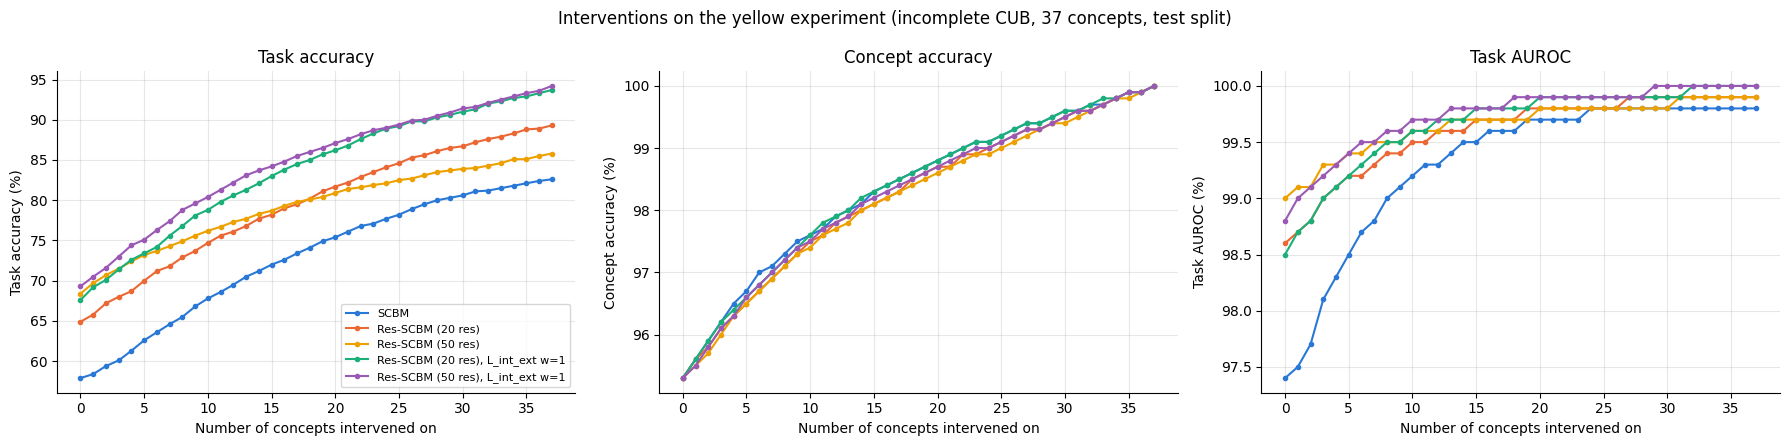

,model,y_acc @ 0,y_acc @ 18,y_acc @ 37
0,SCBM,57.9,74.1,82.6
1,Res-SCBM (20 res),64.9,80.2,89.3
2,Res-SCBM (50 res),68.4,80.1,85.8
3,"Res-SCBM (20 res), L_int_ext w=1",67.6,85.0,93.7
4,"Res-SCBM (50 res), L_int_ext w=1",69.3,86.0,94.2


In [132]:
# ---- Intervention curves for the yellow experiment ----
# Strategy is emp_perc / random policy on the test split for all five runs (see the log header).
PANELS = [("y_accuracy", "Task accuracy (%)"),
          ("c_accuracy", "Concept accuracy (%)"),
          ("y_AUROC", "Task AUROC (%)")]

fig, axes = plt.subplots(1, len(PANELS), figsize=(6 * len(PANELS), 4.5), sharex=True)
for ax, (metric, ylabel) in zip(axes, PANELS):
    for label, model_type, run_dir in YELLOW_RUNS:
        xs, curves = extract_info_from_intervention_log(run_dir, model_type=model_type, dataset="CUB")
        ys = curves[metric]
        keep = [(x, y) for x, y in zip(xs, ys) if y is not None]
        ax.plot([x for x, _ in keep], [y for _, y in keep], marker="o", markersize=3,
                color=YELLOW_COLORS[label], label=label)
    ax.set_xlabel("Number of concepts intervened on")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel.split(" (")[0])
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].legend(fontsize=8)
fig.suptitle("Interventions on the yellow experiment (incomplete CUB, 37 concepts, test split)")
plt.tight_layout()
plt.savefig(os.path.join("plots", "yellow_experiment_intervention_curves.png"), dpi=200)
plt.show()

# Task accuracy at 0 / half / all concepts intervened, for the table.
rows = []
for label, model_type, run_dir in YELLOW_RUNS:
    xs, curves = extract_info_from_intervention_log(run_dir, model_type=model_type, dataset="CUB")
    by_x = dict(zip(xs, curves["y_accuracy"]))
    rows.append({"model": label, **{f"y_acc @ {n}": by_x.get(n) for n in (0, max(xs) // 2, max(xs))}})
df_yellow_int = pd.DataFrame(rows)
df_yellow_int.to_csv(os.path.join(root_save_dir, "yellow_experiment_intervention_curves.csv"), index=False)
df_yellow_int

## Model comparison on a set of classes

Linear head vs Res-SCBM (20 res, L_int_ext w=1) side by side, for any class
list -- e.g. one collision group, where the two models should behave differently:
the head reads only the 37 surviving concepts and cannot separate a group at all,
while the residual channel can.

In [133]:
# Same ordering as per_class_overview / cell above, so group indices match the printouts.
ordered_groups = sorted(groups_37, key=lambda g: (-len(g), g[0]))


def _frame_or_csv(df, var_name, csv_name):
    """The named frame if the cell that builds it has been run, else its saved CSV."""
    if df is None:
        df = globals().get(var_name)
    if df is None:
        df = pd.read_csv(os.path.join(root_save_dir, csv_name))
    return df


def compare_models_on_classes(class_labels, title="", df_lin=None, df_res=None):
    """Per-class accuracy for both models, restricted to class_labels.

    Defaults to the two frames built above: df_acc (linear head, cell '## Linear
    classifier') and df_acc_res20_lint (Res-SCBM 20 res, L_int_ext w=1).
    """
    df_lin = _frame_or_csv(df_lin, "df_acc",
                           "yellow_experiment_linear_head_per_class_acc.csv")
    df_res = _frame_or_csv(df_res, "df_acc_res20_lint",
                           "yellow_experiment_res_scbm_20_L_int_ext_per_class_acc.csv")

    m = (df_lin[["class_label", "class_name", "n_samples", "n_correct", "accuracy"]]
         .merge(df_res[["class_label", "n_correct", "accuracy"]],
                on="class_label", suffixes=("_lin", "_res")))
    m = m[m["class_label"].isin(list(class_labels))].sort_values("class_label")
    m["delta"] = m["accuracy_res"] - m["accuracy_lin"]

    if title:
        print(title)
    print(m.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

    n = m["n_samples"].sum()
    k_lin, k_res = m["n_correct_lin"].sum(), m["n_correct_res"].sum()
    print(f"\ntotal: n={n} | linear head {k_lin/n:.4f} ({k_lin}/{n})"
          f" | res-scbm L_int_ext {k_res/n:.4f} ({k_res}/{n})")
    return m


g = 0
df_group0 = compare_models_on_classes(
    ordered_groups[g],
    f"Group {g} - {len(ordered_groups[g])} classes")

display(df_group0)


Group 0 - 5 classes
 class_label                    class_name  n_samples  n_correct_lin  accuracy_lin  n_correct_res  accuracy_res  delta
          41      042.Vermilion_Flycatcher         30              0         0.000             22         0.733  0.733
          42 043.Yellow_bellied_Flycatcher         29              0         0.000              9         0.310  0.310
         162          163.Cape_May_Warbler         30              0         0.000             25         0.833  0.833
         172    173.Orange_crowned_Warbler         30             30         1.000             10         0.333 -0.667
         173              174.Palm_Warbler         30              0         0.000              3         0.100  0.100

total: n=149 | linear head 0.2013 (30/149) | res-scbm L_int_ext 0.4631 (69/149)


,class_label,class_name,n_samples,n_correct_lin,accuracy_lin,n_correct_res,accuracy_res,delta
41,41,042.Vermilion_Flycatcher,30,0,0.0,22,0.733333,0.733333
42,42,043.Yellow_bellied_Flycatcher,29,0,0.0,9,0.310345,0.310345
162,162,163.Cape_May_Warbler,30,0,0.0,25,0.833333,0.833333
172,172,173.Orange_crowned_Warbler,30,30,1.0,10,0.333333,-0.666667
173,173,174.Palm_Warbler,30,0,0.0,3,0.100000,0.100000


In [134]:
g = 8
df_group8 = compare_models_on_classes(
    ordered_groups[g],
    f"Group {g} - {len(ordered_groups[g])} classes")

display(df_group8)

Group 8 - 2 classes
 class_label               class_name  n_samples  n_correct_lin  accuracy_lin  n_correct_res  accuracy_res  delta
          19 020.Yellow_breasted_Chat         29             29         1.000             22         0.759 -0.241
         127      128.Seaside_Sparrow         30              0         0.000             19         0.633  0.633

total: n=59 | linear head 0.4915 (29/59) | res-scbm L_int_ext 0.6949 (41/59)


,class_label,class_name,n_samples,n_correct_lin,accuracy_lin,n_correct_res,accuracy_res,delta
19,19,020.Yellow_breasted_Chat,29,29,1.0,22,0.758621,-0.241379
127,127,128.Seaside_Sparrow,30,0,0.0,19,0.633333,0.633333


In [135]:
g = 15
df_group15 = compare_models_on_classes(
    ordered_groups[g],
    f"Group {g} - {len(ordered_groups[g])} classes")

display(df_group15)

Group 15 - 2 classes
 class_label             class_name  n_samples  n_correct_lin  accuracy_lin  n_correct_res  accuracy_res  delta
          76  077.Tropical_Kingbird         30             30         1.000             25         0.833 -0.167
         152 153.Philadelphia_Vireo         29              0         0.000             15         0.517  0.517

total: n=59 | linear head 0.5085 (30/59) | res-scbm L_int_ext 0.6780 (40/59)


,class_label,class_name,n_samples,n_correct_lin,accuracy_lin,n_correct_res,accuracy_res,delta
76,76,077.Tropical_Kingbird,30,30,1.0,25,0.833333,-0.166667
152,152,153.Philadelphia_Vireo,29,0,0.0,15,0.517241,0.517241


## Inspect covariance matrices

042.Vermilion_Flycatcher: 30 test samples, cov (30, 57, 57)


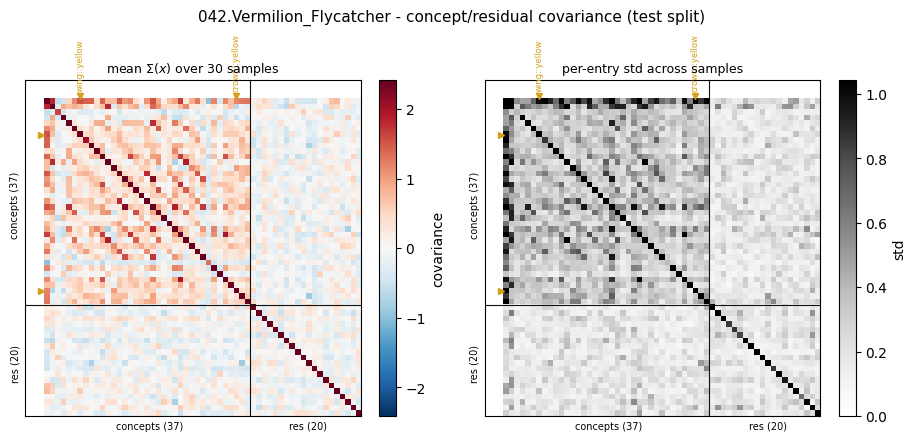

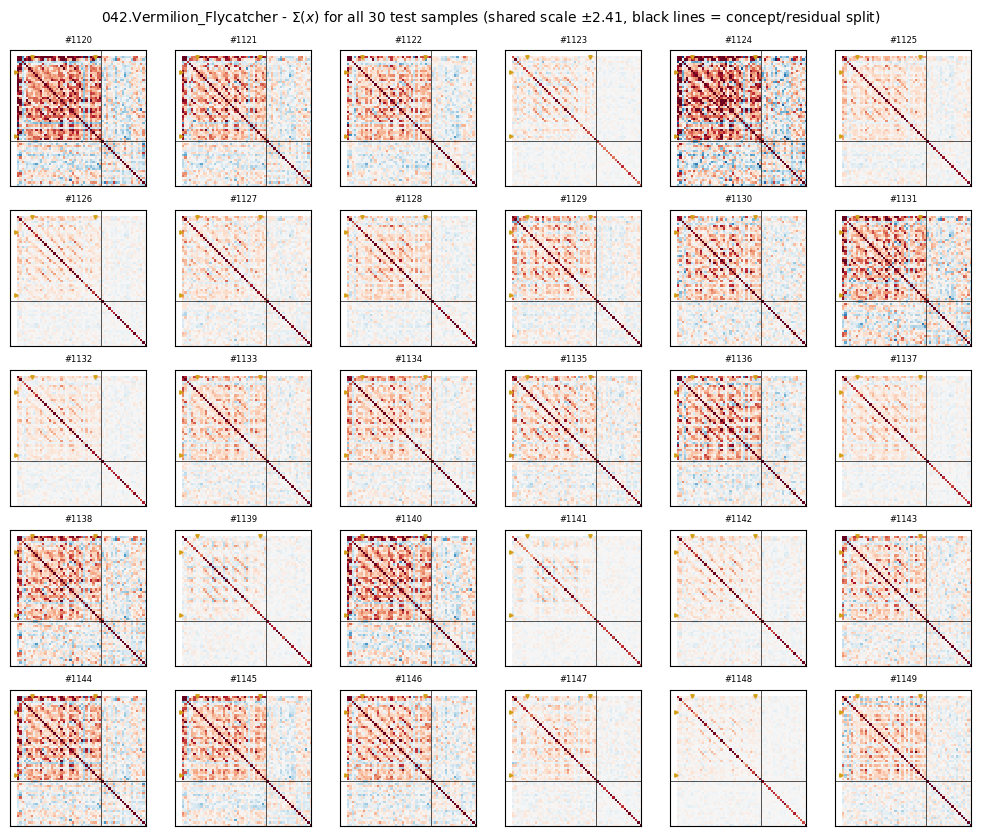

||Sigma - mean||_F / ||mean||_F : min 0.193 med 0.477 max 1.429
cross-block |Sigma_cr| mean 0.2294 max 2.4174


In [136]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

RUN = os.path.join(
    "experiments", "scbm_residual", "CUB",
    "yellow_experiment_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-09-02_16-12-55_d1750")
N_C, N_R = 37, 20                       # 37 surviving concepts | 20 residuals
OUT = "plots"

CLASS_LABEL, CLASS_NAME = 41, "042.Vermilion_Flycatcher"
# group 0: 41 Vermilion_Flycatcher, 42 Yellow_bellied_Flycatcher,
#          162 Cape_May_Warbler, 172 Orange_crowned_Warbler, 173 Palm_Warbler

y = torch.load(f"{RUN}/test/y_true.pt", map_location="cpu").numpy().ravel()
rows = np.flatnonzero(y == CLASS_LABEL)
cov = torch.load(f"{RUN}/test/covariance_matrices.pt", map_location="cpu").float().numpy()[rows]
print(f"{CLASS_NAME}: {len(rows)} test samples, cov {cov.shape}")

# Colour limit from the off-diagonal only -- the diagonal holds the variances and
# is ~20x larger, so including it would wash out all cross-term structure.
off = ~np.eye(N_C + N_R, dtype=bool)
v = np.percentile(np.abs(cov[:, off]), 99.5)


# The two yellow attributes that survive the yellow_experiment_local_1 removal
# (every other yellow attribute is a hidden concept). Indices are in the 37-dim
# surviving space; see the info.txt mapping cell above.
YELLOW_AXES = {6: "wing::yellow", 34: "crown::yellow"}
YELLOW = "#d4a017"


def blocks(ax, lw=0.8, names=False):
    """Mark the concept/residual split and the two surviving yellow concepts."""
    ax.axhline(N_C - .5, color="#111", lw=lw)
    ax.axvline(N_C - .5, color="#111", lw=lw)

    # Markers sit just outside the image so they never cover the cells of interest.
    pad = 1.0 if names else 0.8
    for i, nm in YELLOW_AXES.items():
        ax.plot(-pad, i, marker=">", ms=4 if names else 2.5, color=YELLOW, clip_on=False)
        ax.plot(i, -pad, marker="v", ms=4 if names else 2.5, color=YELLOW, clip_on=False)
        if names:
            ax.text(i, -1.8, nm, rotation=90, ha="center", va="bottom",
                    fontsize=6, color=YELLOW)

    ax.set_xticks([N_C / 2, N_C + N_R / 2])
    ax.set_yticks([N_C / 2, N_C + N_R / 2])
    ax.set_xticklabels(["concepts (37)", "res (20)"], fontsize=7)
    ax.set_yticklabels(["concepts (37)", "res (20)"], fontsize=7, rotation=90, va="center")
    ax.tick_params(length=0)


# ---- mean over the class's samples, and how much it varies ---------------
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.3), constrained_layout=True)
m = cov.mean(0)
im = axes[0].imshow(m, cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
axes[0].set_title(f"mean $\\Sigma(x)$ over {len(rows)} samples", fontsize=9)
fig.colorbar(im, ax=axes[0], fraction=.046, label="covariance")

s = cov.std(0)
im2 = axes[1].imshow(s, cmap="Greys", vmin=0, vmax=np.percentile(s[off], 99.5),
                     interpolation="nearest")
axes[1].set_title("per-entry std across samples", fontsize=9)
fig.colorbar(im2, ax=axes[1], fraction=.046, label="std")

for ax in axes:
    blocks(ax, names=True)
fig.suptitle(f"{CLASS_NAME} - concept/residual covariance (test split)", fontsize=11)
fig.savefig(f"{OUT}/cov_{CLASS_NAME}_mean.png", dpi=170)
plt.show()

# ---- every sample, shared colour scale ----------------------------------
n, ncol = len(rows), 6
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(1.65 * ncol, 1.65 * nrow), constrained_layout=True)
for i, ax in enumerate(axes.ravel()):
    if i >= n:
        ax.axis("off")
        continue
    ax.imshow(cov[i], cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
    blocks(ax, lw=.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"#{rows[i]}", fontsize=6)
fig.suptitle(f"{CLASS_NAME} - $\\Sigma(x)$ for all {n} test samples "
             f"(shared scale $\\pm${v:.2f}, black lines = concept/residual split)", fontsize=10)
fig.savefig(f"{OUT}/cov_{CLASS_NAME}_all_samples.png", dpi=170)
plt.show()

# ---- how input-dependent is Sigma within this class? --------------------
fro = np.linalg.norm(cov - m, axis=(1, 2)) / np.linalg.norm(m)
print(f"||Sigma - mean||_F / ||mean||_F : min {fro.min():.3f} "
      f"med {np.median(fro):.3f} max {fro.max():.3f}")
cr = cov[:, :N_C, N_C:]
print(f"cross-block |Sigma_cr| mean {np.abs(cr).mean():.4f} max {np.abs(cr).max():.4f}")


### Correlation matrices

Same three views on `corr(Sigma(x))` instead of `Sigma(x)`. The residual block
carries much larger variances than the concept block, so raw covariance
under-reads concept-residual dependence relative to within-block dependence;
normalising puts every entry on the same [-1, 1] scale. `block_diagonal_cov` is
`False` for this run, so the cross block is free -- nothing but the L1 precision
penalty pushes it toward zero.

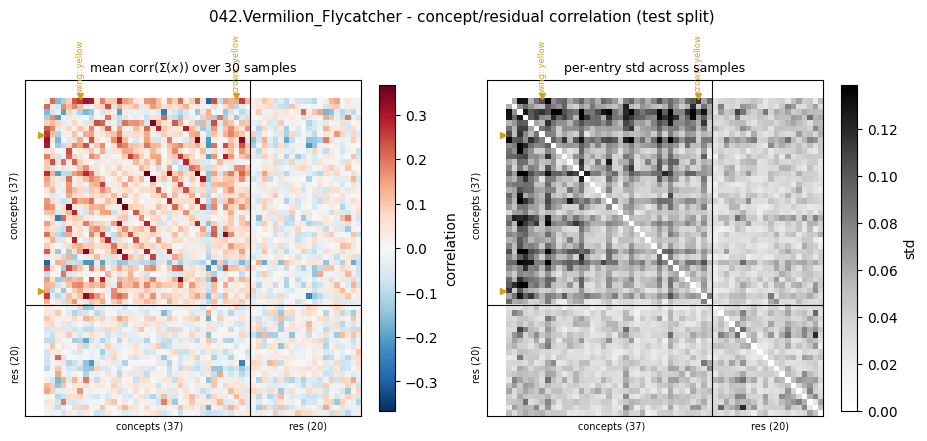

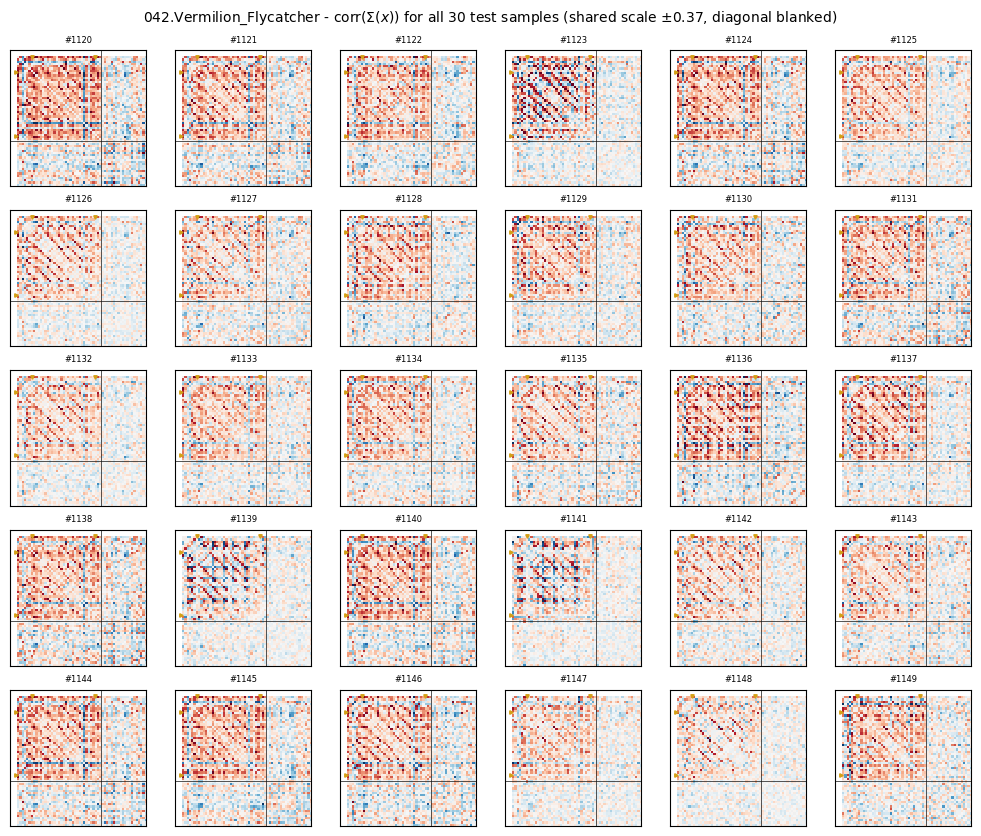

block                 mean|r|   p99|r|   max|r|  frac>0.1
concept-concept        0.1064   0.3804   0.6542    0.4351
residual-residual      0.0606   0.2163   0.3629    0.1826
concept-residual       0.0580   0.2123   0.3660    0.1693


In [137]:
# ---- the same three views, on the correlation matrices -------------------
# corr = D Sigma D with D = diag(1/sqrt(diag Sigma)). This strips the per-dimension
# variance scale, which matters here: the residual block carries far more variance
# than the concept block, so in Sigma a strong concept-residual dependence and a
# weak one look similar. In corr every entry is on the same [-1, 1] scale.
d = np.sqrt(np.einsum("...ii->...i", cov))              # [n, C+R] per-dim std
corr = cov / (d[:, :, None] * d[:, None, :])
corr = np.clip(corr, -1.0, 1.0)                         # guard float32 drift

diag = np.eye(N_C + N_R, dtype=bool)
vc = np.percentile(np.abs(corr[:, off]), 99.5)
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#f0f0f0")                                 # masked diagonal


def no_diag(a):
    """Blank the diagonal -- it is identically 1 and would saturate the scale."""
    a = a.copy()
    a[..., diag] = np.nan
    return a


# ---- mean over the class's samples, and how much it varies ---------------
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.3), constrained_layout=True)
mc = corr.mean(0)
im = axes[0].imshow(no_diag(mc), cmap=cmap, vmin=-vc, vmax=vc, interpolation="nearest")
axes[0].set_title(f"mean corr($\\Sigma(x)$) over {len(rows)} samples", fontsize=9)
fig.colorbar(im, ax=axes[0], fraction=.046, label="correlation")

sc = corr.std(0)
im2 = axes[1].imshow(no_diag(sc), cmap="Greys", vmin=0,
                     vmax=np.percentile(sc[off], 99.5), interpolation="nearest")
axes[1].set_title("per-entry std across samples", fontsize=9)
fig.colorbar(im2, ax=axes[1], fraction=.046, label="std")

for ax in axes:
    blocks(ax, names=True)
fig.suptitle(f"{CLASS_NAME} - concept/residual correlation (test split)", fontsize=11)
fig.savefig(f"{OUT}/corr_{CLASS_NAME}_mean.png", dpi=170)
plt.show()

# ---- every sample, shared colour scale ----------------------------------
fig, axes = plt.subplots(nrow, ncol, figsize=(1.65 * ncol, 1.65 * nrow),
                         constrained_layout=True)
for i, ax in enumerate(axes.ravel()):
    if i >= n:
        ax.axis("off")
        continue
    ax.imshow(no_diag(corr[i]), cmap=cmap, vmin=-vc, vmax=vc, interpolation="nearest")
    blocks(ax, lw=.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"#{rows[i]}", fontsize=6)
fig.suptitle(f"{CLASS_NAME} - corr($\\Sigma(x)$) for all {n} test samples "
             f"(shared scale $\\pm${vc:.2f}, diagonal blanked)", fontsize=10)
fig.savefig(f"{OUT}/corr_{CLASS_NAME}_all_samples.png", dpi=170)
plt.show()

# ---- block-wise summary -------------------------------------------------
# The concept-residual block is the one that matters for the leakage question:
# block_diagonal_cov=False, so nothing forces it to zero.
blk = {
    "concept-concept": corr[:, :N_C, :N_C][:, ~np.eye(N_C, dtype=bool)],
    "residual-residual": corr[:, N_C:, N_C:][:, ~np.eye(N_R, dtype=bool)],
    "concept-residual": corr[:, :N_C, N_C:].reshape(n, -1),
}
print(f"{'block':<20}{'mean|r|':>9}{'p99|r|':>9}{'max|r|':>9}{'frac>0.1':>10}")
for name, a in blk.items():
    a = np.abs(a)
    print(f"{name:<20}{a.mean():>9.4f}{np.percentile(a, 99):>9.4f}"
          f"{a.max():>9.4f}{(a > 0.1).mean():>10.4f}")

In [138]:
YELLOW_KEPT = {6: "has_wing_color::yellow", 34: "has_crown_color::yellow"}
other = [c for c in range(N_C) if c not in YELLOW_KEPT]

cr = np.abs(corr[:, :N_C, N_C:])          # [n, C, R]
null = cr[:, other, :].mean()             # mean |r| over non-yellow concept rows

print(f"{'concept':<28}{'mean|r|':>9}{'max|r|':>9}{'argmax dim':>12}{'vs null':>9}")
for ci, cname in YELLOW_KEPT.items():
    row = cr[:, ci, :]                    # [n, R]
    per_dim = row.mean(0)                 # [R]
    print(f"{cname:<28}{row.mean():>9.4f}{per_dim.max():>9.4f}"
          f"{int(per_dim.argmax()):>12}{row.mean()/null:>9.2f}x")
print(f"{'(null: other 35 concepts)':<28}{null:>9.4f}")

# signed per-dim profile -- the thing to compare across classes
prof = corr[:, list(YELLOW_KEPT), N_C:].mean(0)   # [2, R]

concept                       mean|r|   max|r|  argmax dim  vs null
has_wing_color::yellow         0.0651   0.1650          15     1.12x
has_crown_color::yellow        0.0502   0.1189          16     0.86x
(null: other 35 concepts)      0.0580


### Covariance of the logits: total = between + within

`Sigma(x)` above is the **conditional** covariance of `eta` given one image --
the model's leftover uncertainty after seeing that photo. It is *not* the
covariance of the logits over the dataset. The law of total covariance splits
those apart:

    Cov(eta)  =  Cov_x( mu(x) )  +  E_x[ Sigma(x) ]
     total        between            within

Only the *within* term is what the L1 precision penalty regularises, and only
the *within* term is what the panels above show. The concept-residual coupling
that step 3 of the pipeline removes (OLS-residualising `res_mu` on `c_mu`) lives
almost entirely in the **between** term. So an empty cross block in `Sigma(x)`
says nothing about leakage -- reading it that way under-reads the coupling by
roughly an order of magnitude.

Note the covariance row shares one colour scale across all three panels, which
is why `within` looks blank: that magnitude gap is the point. The correlation
row rescales each matrix so the within-block structure is visible again.

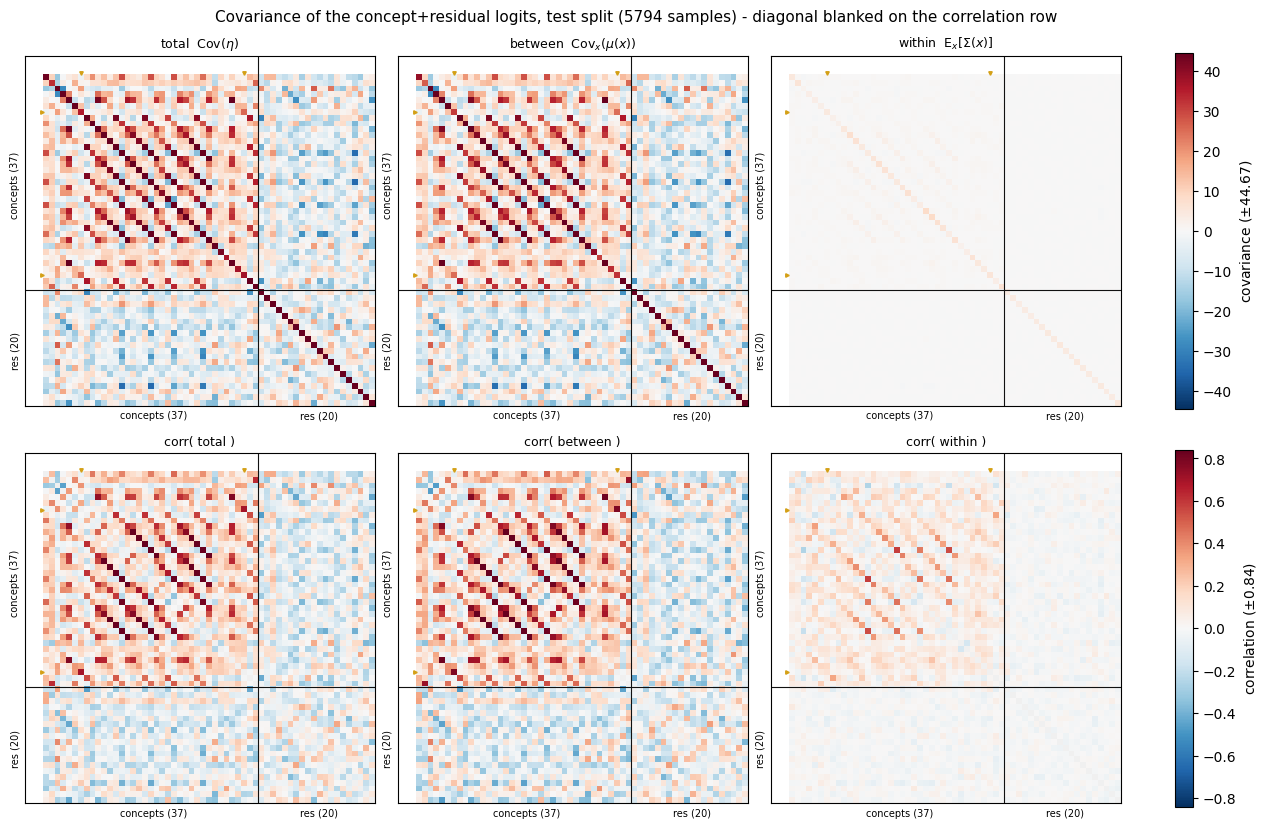

matrix      block                 mean|r|   max|r|  trace share
total       concept-concept        0.2042   0.9235        0.645
total       concept-residual       0.1279   0.4640            -
total       residual-residual      0.1095   0.3613        0.355
between     concept-concept        0.2197   0.9371        0.641
between     concept-residual       0.1381   0.4830            -
between     residual-residual      0.1169   0.3811        0.359
within      concept-concept        0.0815   0.5836        0.687
within      concept-residual       0.0222   0.0997            -
within      residual-residual      0.0178   0.0715        0.313

variance of the logits that is between-sample: 0.922 (concepts 0.917, residuals 0.932)
OLS c_mu -> res_mu  R^2 (in-sample, test split) = 0.737


In [139]:
# ---- covariance of the logits themselves: total = between + within -------
# Sigma(x) above is the *conditional* covariance -- the model's leftover
# uncertainty about eta given this one image. It is not the covariance of the
# logits over the dataset. The two differ by the between-sample term:
#
#     Cov(eta)   =   Cov_x( mu(x) )   +   E_x[ Sigma(x) ]
#      total          between/signal       within/noise
#
# This matters for the cleaning step: the concept-residual coupling that the
# c_mu -> res_mu regression removes lives almost entirely in the *between*
# term, so the cross block of Sigma(x) can look empty while c_mu still
# predicts res_mu almost perfectly. Reading Sigma(x) alone under-reads the
# leakage by an order of magnitude.

mu = torch.load(f"{RUN}/test/c_res_mu.pt", map_location="cpu").double().numpy()
S_x = torch.load(f"{RUN}/test/covariance_matrices.pt", map_location="cpu").double().numpy()
n_test, D = mu.shape
assert D == N_C + N_R and S_x.shape[0] == n_test

within = S_x.mean(0)                                  # E_x[Sigma(x)]
mu_c = mu - mu.mean(0)
between = mu_c.T @ mu_c / (n_test - 1)                # Cov_x(mu(x))
total = between + within

MATS = [("total  Cov($\\eta$)", total),
        ("between  Cov$_x(\\mu(x))$", between),
        ("within  E$_x[\\Sigma(x)]$", within)]


def to_corr(M):
    d = np.sqrt(np.diag(M))
    return np.clip(M / np.outer(d, d), -1.0, 1.0)


# Shared scale within each row, so the three panels are directly comparable:
# on the covariance row this is what makes between >> within visible at a glance.
v_cov = np.percentile(np.abs(np.stack([M for _, M in MATS])[:, off]), 99.5)
v_cor = np.percentile(np.abs(np.stack([to_corr(M) for _, M in MATS])[:, off]), 99.5)

fig, axes = plt.subplots(2, 3, figsize=(12.6, 8.2), constrained_layout=True)
for j, (name, M) in enumerate(MATS):
    im = axes[0, j].imshow(M, cmap="RdBu_r", vmin=-v_cov, vmax=v_cov,
                           interpolation="nearest")
    axes[0, j].set_title(name, fontsize=9)

    im2 = axes[1, j].imshow(no_diag(to_corr(M)), cmap=cmap, vmin=-v_cor, vmax=v_cor,
                            interpolation="nearest")
    axes[1, j].set_title("corr( " + name.split("  ")[0] + " )", fontsize=9)

fig.colorbar(im, ax=axes[0, :], fraction=.025, label=f"covariance ($\\pm${v_cov:.2f})")
fig.colorbar(im2, ax=axes[1, :], fraction=.025, label=f"correlation ($\\pm${v_cor:.2f})")
for ax in axes.ravel():
    blocks(ax, names=False)
fig.suptitle("Covariance of the concept+residual logits, test split "
             f"({n_test} samples) - diagonal blanked on the correlation row", fontsize=11)
fig.savefig(f"{OUT}/logit_cov_decomposition.png", dpi=170)
plt.show()

# ---- block-wise numbers behind the picture ------------------------------
oc, orr = ~np.eye(N_C, dtype=bool), ~np.eye(N_R, dtype=bool)
print(f"{'matrix':<12}{'block':<20}{'mean|r|':>9}{'max|r|':>9}{'trace share':>13}")
for name, M in MATS:
    R_ = to_corr(M)
    short = name.split("  ")[0]
    for bname, a in (("concept-concept", R_[:N_C, :N_C][oc]),
                     ("concept-residual", R_[:N_C, N_C:].ravel()),
                     ("residual-residual", R_[N_C:, N_C:][orr])):
        a = np.abs(a)
        share = (np.trace(M[:N_C, :N_C]) if "concept-concept" in bname
                 else np.trace(M[N_C:, N_C:]) if "residual-residual" in bname else np.nan)
        share = share / np.trace(M) if share == share else np.nan
        tail = f"{share:>13.3f}" if share == share else f"{'-':>13}"
        print(f"{short:<12}{bname:<20}{a.mean():>9.4f}{a.max():>9.4f}{tail}")

print(f"\nvariance of the logits that is between-sample: "
      f"{np.trace(between) / np.trace(total):.3f} "
      f"(concepts {np.trace(between[:N_C, :N_C]) / np.trace(total[:N_C, :N_C]):.3f}, "
      f"residuals {np.trace(between[N_C:, N_C:]) / np.trace(total[N_C:, N_C:]):.3f})")

# OLS c_mu -> res_mu on the same means: the quantity the cleaning step acts on.
A = np.c_[mu[:, :N_C], np.ones(n_test)]
W, *_ = np.linalg.lstsq(A, mu[:, N_C:], rcond=None)
r2 = 1 - (mu[:, N_C:] - A @ W).var(0).sum() / mu[:, N_C:].var(0).sum()
print(f"OLS c_mu -> res_mu  R^2 (in-sample, test split) = {r2:.3f}")